# Lead Scoring Prediction System

## Project Overview

X Education is an online education company that generates a large number of leads through various online marketing channels. However, only around **30% of these leads convert into paying customers**, resulting in inefficient use of the sales team's time and resources.

Currently, the sales team follows up with all leads equally, regardless of their likelihood of conversion. This approach increases operational costs and reduces overall efficiency.

The objective of this project is to build a **machine learning-based Lead Scoring System** that predicts the probability of a lead converting into a customer. Based on this probability, each lead will be assigned a **Lead Score (0–100)**, allowing the sales team to prioritize high-potential prospects and improve the conversion process.

This project follows a complete end-to-end machine learning pipeline, including:

- Data Understanding
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Model Building
- Model Evaluation
- Lead Score Prediction
- Business Insights

# Business Problem Statement

X Education receives thousands of leads through various online channels such as websites, search engines, referrals, and advertisements. Despite this large volume of leads, only about **30%** successfully convert into customers.

Since every lead is treated equally, the sales team spends valuable time contacting low-potential leads instead of focusing on those who are more likely to convert.

The business needs a **data-driven Lead Scoring System** that can:

- Predict the likelihood of conversion for each lead.
- Assign a Lead Score between **0 and 100**.
- Help the sales team prioritize high-quality leads.
- Improve sales efficiency and optimize resource allocation.
- Support the company's goal of increasing the overall conversion rate.

By leveraging machine learning, the organization can make smarter sales decisions and improve customer acquisition.

# Project Objective

The primary objective of this project is to develop a predictive machine learning model capable of identifying potential customers from incoming leads.

The model will:

- Analyze historical lead information.
- Learn patterns associated with successful conversions.
- Predict whether a new lead is likely to convert.
- Generate a Lead Score based on the predicted probability.
- Enable the sales team to prioritize high-value leads for follow-up.

### Expected Outcomes

- Improve lead prioritization.
- Reduce time spent on low-quality leads.
- Increase sales efficiency.
- Support better business decision-making.

In [208]:
# ============================================
# Import Required Libraries
# ============================================

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Set Visualization Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


# Load the Dataset

In this section, we load the Lead Scoring dataset into a Pandas DataFrame and perform an initial inspection to verify that the dataset has been imported successfully.

This helps us understand the dataset's dimensions before beginning any preprocessing or analysis.

In [209]:
# Load the dataset

df = pd.read_csv("Lead Scoring.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [210]:
# Display first 5 rows

df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [211]:
# Display last 5 rows

df.tail()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
9235,19d6451e-fcd6-407c-b83b-48e1af805ea9,579564,Landing Page Submission,Direct Traffic,Yes,No,1,8.0,1845,2.67,...,No,Potential Lead,Mumbai,02.Medium,01.High,15.0,17.0,No,No,Email Marked Spam
9236,82a7005b-7196-4d56-95ce-a79f937a158d,579546,Landing Page Submission,Direct Traffic,No,No,0,2.0,238,2.00,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,19.0,No,Yes,SMS Sent
9237,aac550fe-a586-452d-8d3c-f1b62c94e02c,579545,Landing Page Submission,Direct Traffic,Yes,No,0,2.0,199,2.00,...,No,Potential Lead,Mumbai,02.Medium,01.High,13.0,20.0,No,Yes,SMS Sent
9238,5330a7d1-2f2b-4df4-85d6-64ca2f6b95b9,579538,Landing Page Submission,Google,No,No,1,3.0,499,3.00,...,No,NaN,Other Metro Cities,02.Medium,02.Medium,15.0,16.0,No,No,SMS Sent
9239,571b5c8e-a5b2-4d57-8574-f2ffb06fdeff,579533,Landing Page Submission,Direct Traffic,No,No,1,6.0,1279,3.00,...,No,Potential Lead,Other Cities,02.Medium,01.High,15.0,18.0,No,Yes,Modified


In [212]:
# Random sample of 5 rows

df.sample(5, random_state=42)

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
4608,8b94b8c4-7107-4c12-8a66-531d0ed974c4,615582,Landing Page Submission,Google,No,No,1,8.0,252,2.67,...,No,Select,Mumbai,NaN,NaN,NaN,NaN,No,Yes,Email Opened
7935,a4c0a4e4-c5d8-4e48-8a4f-030611dde534,588939,Landing Page Submission,Direct Traffic,Yes,No,0,2.0,929,2.00,...,No,NaN,Other Cities,02.Medium,02.Medium,14.0,16.0,No,Yes,Modified
4043,889c23c8-84d0-4936-97ad-7b438dc2e2d7,621242,Landing Page Submission,Direct Traffic,Yes,No,0,1.0,2,1.00,...,No,NaN,Other Cities,NaN,NaN,NaN,NaN,No,No,Modified
7821,85dfdbea-fb6c-4428-a59c-59155bedea4a,589803,Landing Page Submission,Direct Traffic,No,No,0,2.0,323,2.00,...,No,Select,Mumbai,02.Medium,01.High,14.0,18.0,No,No,Email Opened
856,cbc292d8-752f-47ea-92c6-07d4247638d5,651441,Landing Page Submission,Google,No,No,0,3.0,201,3.00,...,No,NaN,Mumbai,02.Medium,01.High,13.0,18.0,No,No,Email Opened


In [213]:
rows, cols = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {cols}")

Number of Rows    : 9240
Number of Columns : 37


# Feature Names

The dataset contains multiple features describing customer interactions, demographics, and engagement.

Listing all feature names helps us understand what information is available for model development.

In [214]:
print("Columns in the dataset:\n")

for col in df.columns:
    print(col)

Columns in the dataset:

Prospect ID
Lead Number
Lead Origin
Lead Source
Do Not Email
Do Not Call
Converted
TotalVisits
Total Time Spent on Website
Page Views Per Visit
Last Activity
Country
Specialization
How did you hear about X Education
What is your current occupation
What matters most to you in choosing a course
Search
Magazine
Newspaper Article
X Education Forums
Newspaper
Digital Advertisement
Through Recommendations
Receive More Updates About Our Courses
Tags
Lead Quality
Update me on Supply Chain Content
Get updates on DM Content
Lead Profile
City
Asymmetrique Activity Index
Asymmetrique Profile Index
Asymmetrique Activity Score
Asymmetrique Profile Score
I agree to pay the amount through cheque
A free copy of Mastering The Interview
Last Notable Activity


# Dataset Information

This section provides an overview of:

- Number of observations
- Data types
- Non-null values
- Memory usage

Understanding data types is important because preprocessing techniques differ for numerical and categorical variables.

In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

# Statistical Summary

Descriptive statistics provide insights into the distribution of numerical features such as average values, minimums, maximums, and quartiles.

This helps identify potential outliers and understand the scale of the data.

In [216]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Lead Number,9240.0,617188.435606,23405.995698,579533.0,596484.5,615479.0,637387.25,660737.0
Converted,9240.0,0.385390,0.486714,0.0,0.0,0.0,1.00,1.0
TotalVisits,9103.0,3.445238,4.854853,0.0,1.0,3.0,5.00,251.0
Total Time Spent on Website,9240.0,487.698268,548.021466,0.0,12.0,248.0,936.00,2272.0
Page Views Per Visit,9103.0,2.362820,2.161418,0.0,1.0,2.0,3.00,55.0
Asymmetrique Activity Score,5022.0,14.306252,1.386694,7.0,14.0,14.0,15.00,18.0
Asymmetrique Profile Score,5022.0,16.344883,1.811395,11.0,15.0,16.0,18.00,20.0


In [217]:
print(df.dtypes)

Prospect ID                                       object
Lead Number                                        int64
Lead Origin                                       object
Lead Source                                       object
Do Not Email                                      object
Do Not Call                                       object
Converted                                          int64
TotalVisits                                      float64
Total Time Spent on Website                        int64
Page Views Per Visit                             float64
Last Activity                                     object
Country                                           object
Specialization                                    object
How did you hear about X Education                object
What is your current occupation                   object
What matters most to you in choosing a course     object
Search                                            object
Magazine                       

# Duplicate Record Check

Duplicate records can introduce bias into the model and affect performance.

Therefore, we first check whether duplicate entries exist before performing any preprocessing.

In [218]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


# Missing Value Analysis

Missing values are common in real-world datasets.

Before deciding how to handle them, we first identify which features contain missing values and the percentage of missing data in each feature.

In [219]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing = missing[missing["Missing Values"] > 0]
missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Lead Quality,4767,51.59
Asymmetrique Profile Score,4218,45.65
Asymmetrique Activity Index,4218,45.65
Asymmetrique Activity Score,4218,45.65
Asymmetrique Profile Index,4218,45.65
Tags,3353,36.29
What matters most to you in choosing a course,2709,29.32
Lead Profile,2709,29.32
What is your current occupation,2690,29.11
Country,2461,26.63


# Missing Value Analysis

The previous table shows that several features contain missing values.

Before handling them, we first visualize the percentage of missing values in each feature. This helps us identify columns that may need to be removed or imputed based on the extent of missing data.

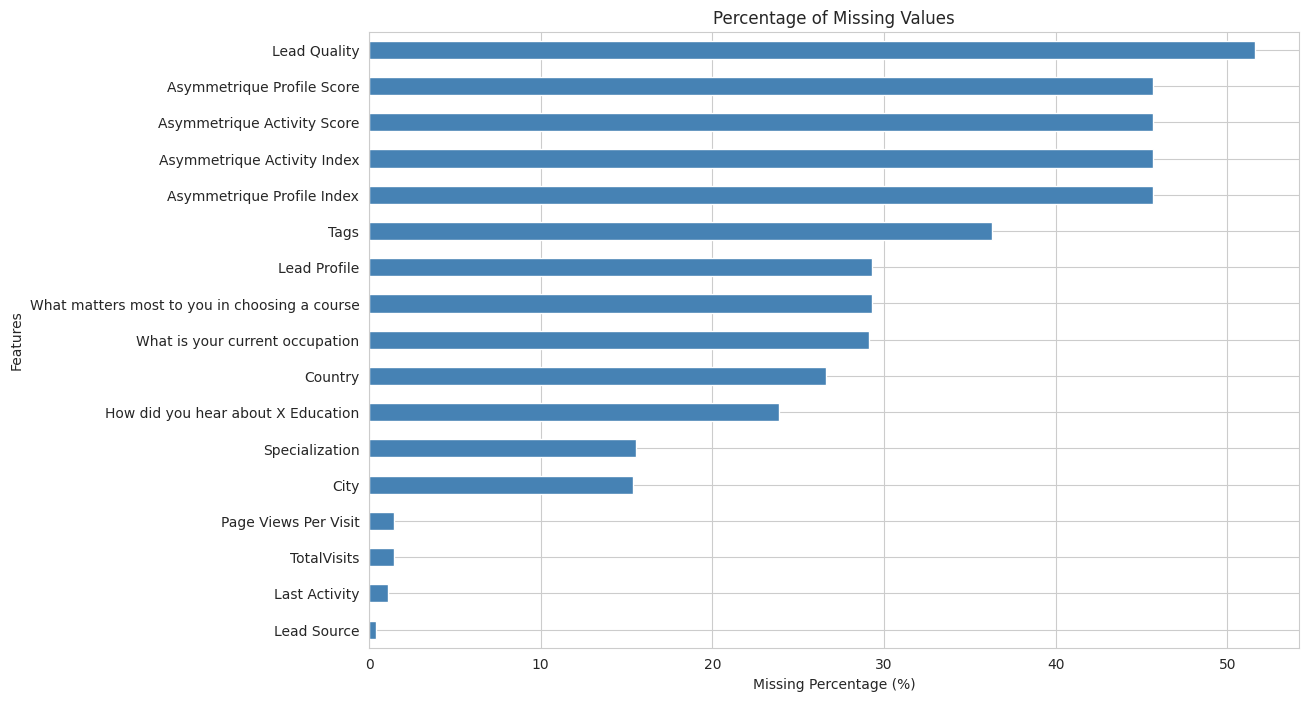

In [220]:
# Visualize Missing Values

plt.figure(figsize=(12,8))

missing.sort_values("Percentage", ascending=True)["Percentage"].plot(kind="barh", color="steelblue")

plt.title("Percentage of Missing Values")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Features")

plt.show()

# Remove Identifier Columns

The columns **Prospect ID** and **Lead Number** are unique identifiers assigned to each lead.

Since they do not contribute to predicting whether a lead will convert, they are removed from the dataset.

In [221]:
# Drop identifier columns

df.drop(["Prospect ID", "Lead Number"], axis=1, inplace=True)

print("Identifier columns removed.")

Identifier columns removed.


In [222]:
missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Lead Quality,4767,51.59
Asymmetrique Profile Score,4218,45.65
Asymmetrique Activity Index,4218,45.65
Asymmetrique Activity Score,4218,45.65
Asymmetrique Profile Index,4218,45.65
Tags,3353,36.29
What matters most to you in choosing a course,2709,29.32
Lead Profile,2709,29.32
What is your current occupation,2690,29.11
Country,2461,26.63


In [223]:
missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Lead Quality,4767,51.59
Asymmetrique Profile Score,4218,45.65
Asymmetrique Activity Index,4218,45.65
Asymmetrique Activity Score,4218,45.65
Asymmetrique Profile Index,4218,45.65
Tags,3353,36.29
What matters most to you in choosing a course,2709,29.32
Lead Profile,2709,29.32
What is your current occupation,2690,29.11
Country,2461,26.63


# Removing Features with High Missing Values

Some features contain a substantial proportion of missing values, making them less reliable for predictive modeling.

The following columns are removed because they contain nearly half or more of their values missing and offer limited practical value for lead scoring:

- Lead Quality
- Asymmetrique Activity Index
- Asymmetrique Activity Score
- Asymmetrique Profile Index
- Asymmetrique Profile Score

Removing these features simplifies the model while reducing the impact of excessive missing data.

In [224]:
# Drop columns with very high missing values

high_missing_cols = [
    "Lead Quality",
    "Asymmetrique Activity Index",
    "Asymmetrique Activity Score",
    "Asymmetrique Profile Index",
    "Asymmetrique Profile Score"
]

df.drop(columns=high_missing_cols, inplace=True)

print(f"Remaining Columns: {df.shape[1]}")

Remaining Columns: 30


In [225]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean() * 100, 2)
})

missing = missing[missing["Missing Values"] > 0]

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Tags,3353,36.29
What matters most to you in choosing a course,2709,29.32
Lead Profile,2709,29.32
What is your current occupation,2690,29.11
Country,2461,26.63
How did you hear about X Education,2207,23.89
Specialization,1438,15.56
City,1420,15.37
Page Views Per Visit,137,1.48
TotalVisits,137,1.48


# Handling Missing Values

After analyzing the missing values, different imputation techniques are applied depending on the nature of each feature.

- Numerical features are imputed using the median to reduce the impact of outliers.
- Categorical features with a small number of missing values are imputed using the mode.
- Features where missing values represent unavailable information are filled with descriptive categories such as "Unknown", "Not Available", or "Not Specified".

This approach preserves valuable information while minimizing data loss.

In [226]:
# ==============================
# Handle Missing Values
# ==============================

# Fill categorical columns
df["Tags"] = df["Tags"].fillna("Not Available")

df["Lead Profile"] = df["Lead Profile"].fillna("Unknown")

df["What is your current occupation"] = df["What is your current occupation"].fillna("Unknown")

df["How did you hear about X Education"] = df["How did you hear about X Education"].fillna("Unknown")

df["Specialization"] = df["Specialization"].fillna("Not Specified")

df["City"] = df["City"].fillna("Unknown")

# Fill mode values
df["Country"] = df["Country"].fillna(df["Country"].mode()[0])

df["What matters most to you in choosing a course"] = \
df["What matters most to you in choosing a course"].fillna(
    df["What matters most to you in choosing a course"].mode()[0]
)

df["Last Activity"] = df["Last Activity"].fillna(
    df["Last Activity"].mode()[0]
)

df["Lead Source"] = df["Lead Source"].fillna(
    df["Lead Source"].mode()[0]
)

# Fill numerical columns
df["TotalVisits"] = df["TotalVisits"].fillna(
    df["TotalVisits"].median()
)

df["Page Views Per Visit"] = df["Page Views Per Visit"].fillna(
    df["Page Views Per Visit"].median()
)

print("Missing values handled successfully.")

Missing values handled successfully.


# Verify Missing Values

After applying the preprocessing steps, we verify that all missing values have been handled successfully.

In [227]:
# Remaining Missing Values

df.isnull().sum().sort_values(ascending=False)

,0
Lead Origin,0
Lead Source,0
Do Not Email,0
Do Not Call,0
Converted,0
TotalVisits,0
Total Time Spent on Website,0
Page Views Per Visit,0
Last Activity,0
Country,0


# Target Variable Analysis

Before building a machine learning model, it is important to understand the distribution of the target variable.

The target feature **Converted** indicates whether a lead was successfully converted into a customer.

Analyzing this distribution helps identify whether the dataset is balanced or imbalanced and provides an understanding of the current business conversion rate.

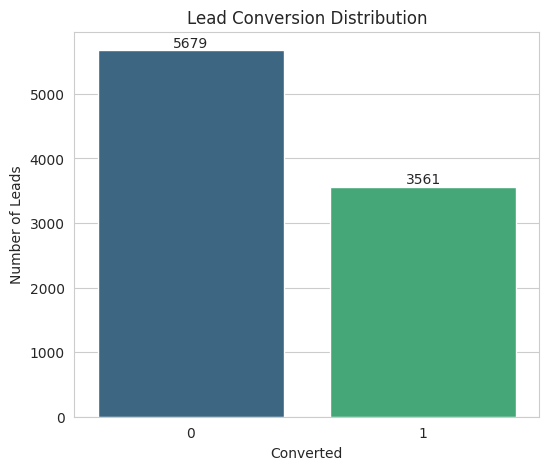

In [228]:
# Target Variable Distribution

plt.figure(figsize=(6,5))

ax = sns.countplot(x='Converted', data=df, palette='viridis')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Lead Conversion Distribution")
plt.xlabel("Converted")
plt.ylabel("Number of Leads")

plt.show()

In [229]:
conversion_rate = df["Converted"].value_counts(normalize=True) * 100

print(conversion_rate)

Converted
0    61.461039
1    38.538961
Name: proportion, dtype: float64


### Business Insight

The dataset shows the proportion of converted and non-converted leads.

This confirms that the company receives a significantly larger number of non-converting leads, highlighting the importance of developing a predictive Lead Scoring model to prioritize high-potential customers.

# Feature Classification

Understanding the data types helps determine the appropriate preprocessing techniques and visualizations.

The features are categorized into:

- Numerical Features
- Categorical Features

In [230]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Number of Numerical Features :", len(numerical_cols))
print("Number of Categorical Features :", len(categorical_cols))

Number of Numerical Features : 4
Number of Categorical Features : 26


In [231]:
print("Numerical Features:\n")
print(numerical_cols)

Numerical Features:

['Converted', 'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']


In [232]:
print("Categorical Features:\n")
print(categorical_cols)

Categorical Features:

['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Tags', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'Lead Profile', 'City', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']


# Distribution of Numerical Features

Visualizing numerical features helps identify their distributions, skewness, and potential outliers.

These observations are useful for selecting appropriate preprocessing and modeling techniques.

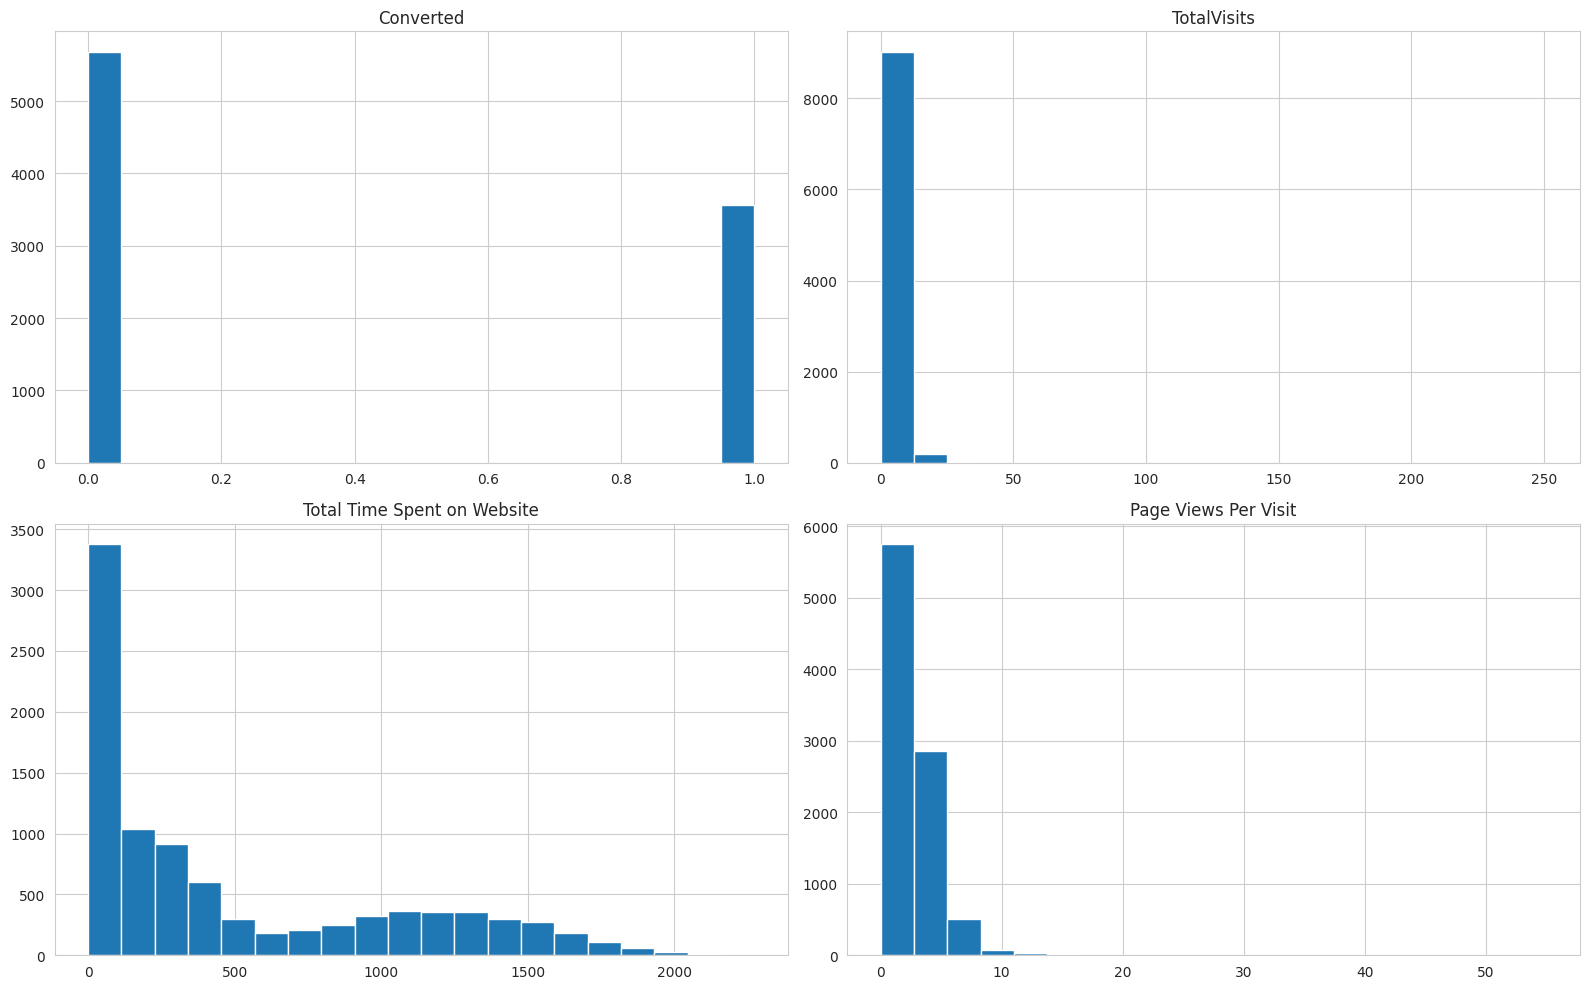

In [233]:
df[numerical_cols].hist(figsize=(16,10), bins=20)

plt.tight_layout()

plt.show()

# Correlation Analysis

A correlation matrix helps identify relationships among numerical variables.

Highly correlated features may provide similar information, while strong correlations with the target variable can indicate important predictors.

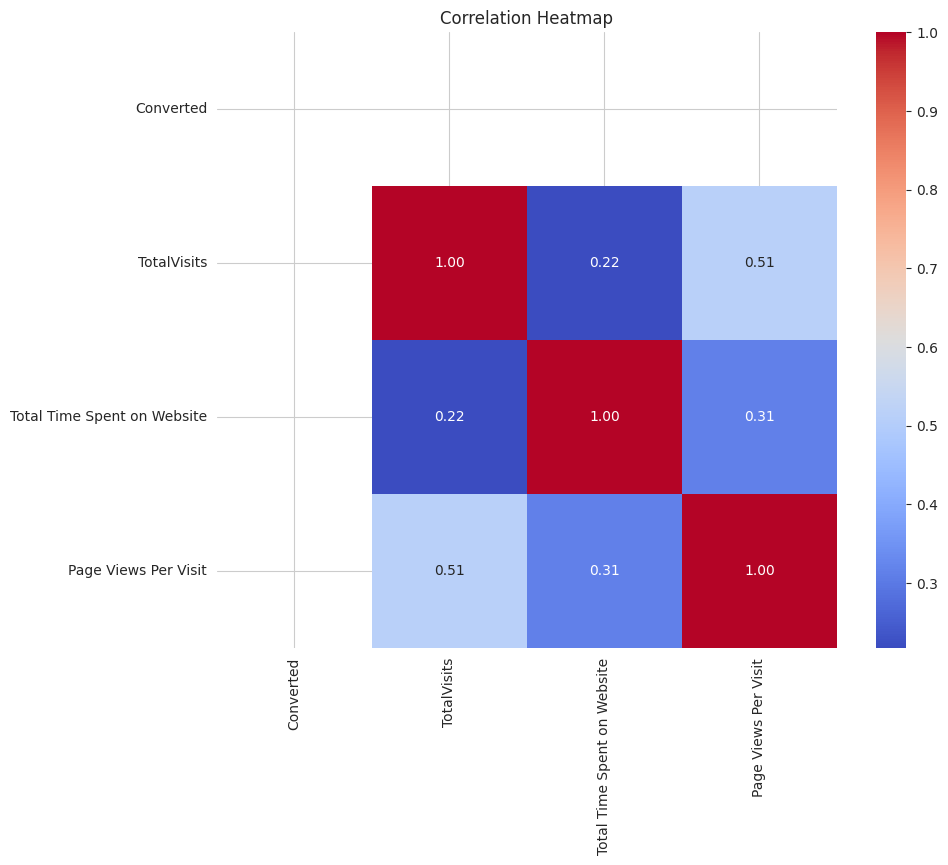

In [234]:
temp = df.copy()

temp["Converted"] = temp["Converted"].map({
    "No":0,
    "Yes":1
})

corr = temp.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

# Total Time Spent on Website vs Conversion

One of the strongest indicators of customer interest is the amount of time spent browsing the website.

This analysis compares website engagement between converted and non-converted leads to understand whether higher engagement leads to higher conversion rates.

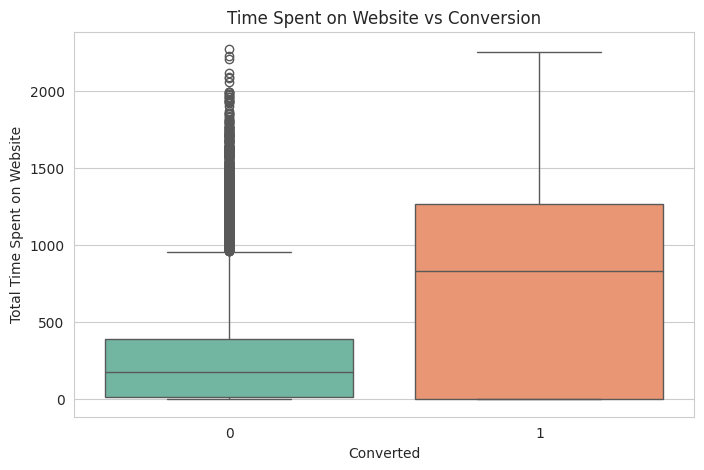

In [235]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Converted",
    y="Total Time Spent on Website",
    data=df,
    palette="Set2"
)

plt.title("Time Spent on Website vs Conversion")

plt.show()

### Business Insight

If converted leads spend noticeably more time on the website than non-converted leads, website engagement can be considered an important indicator of purchase intent.

This feature is expected to contribute significantly to the Lead Scoring model.

# Lead Source vs Conversion

Lead Source indicates where a customer first discovered X Education.

Understanding which sources generate the highest conversion rates helps the marketing and sales teams focus on the most effective acquisition channels.

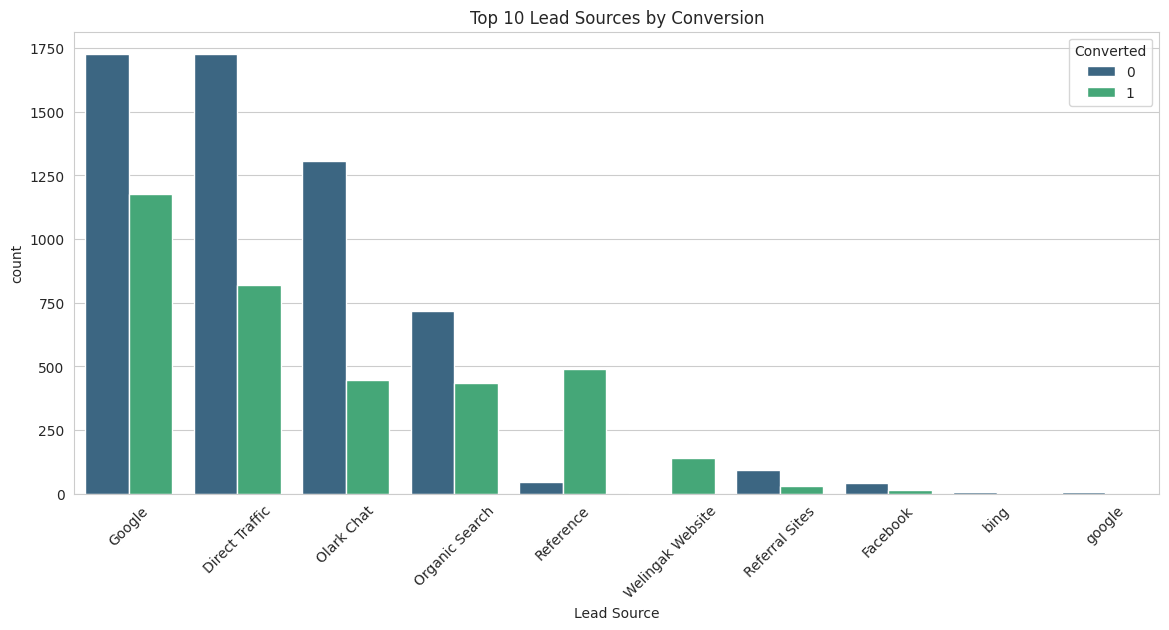

In [236]:
plt.figure(figsize=(14,6))

order = df["Lead Source"].value_counts().head(10).index

sns.countplot(
    data=df,
    x="Lead Source",
    hue="Converted",
    order=order,
    palette="viridis"
)

plt.xticks(rotation=45)
plt.title("Top 10 Lead Sources by Conversion")

plt.show()

### Business Insight

Some lead sources consistently generate more converted leads than others.

Marketing campaigns should prioritize channels that demonstrate higher conversion rates while optimizing spending on lower-performing sources.

# Lead Origin vs Conversion

Lead Origin describes how the lead entered the company's ecosystem.

This analysis identifies which acquisition methods produce higher-quality leads.

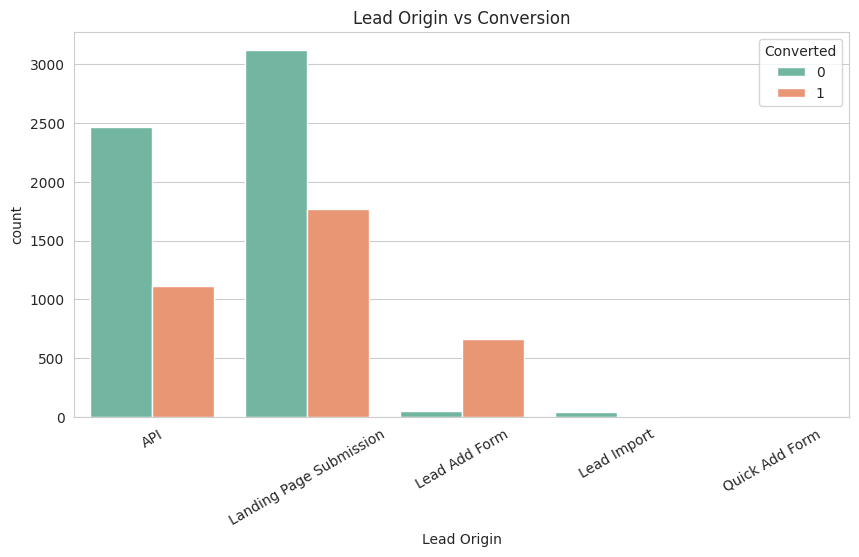

In [237]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Lead Origin",
    hue="Converted",
    palette="Set2"
)

plt.xticks(rotation=30)

plt.title("Lead Origin vs Conversion")

plt.show()

# Occupation vs Conversion

A customer's occupation may influence their likelihood of enrolling in a course.

Analyzing occupation helps identify customer segments with higher conversion potential.

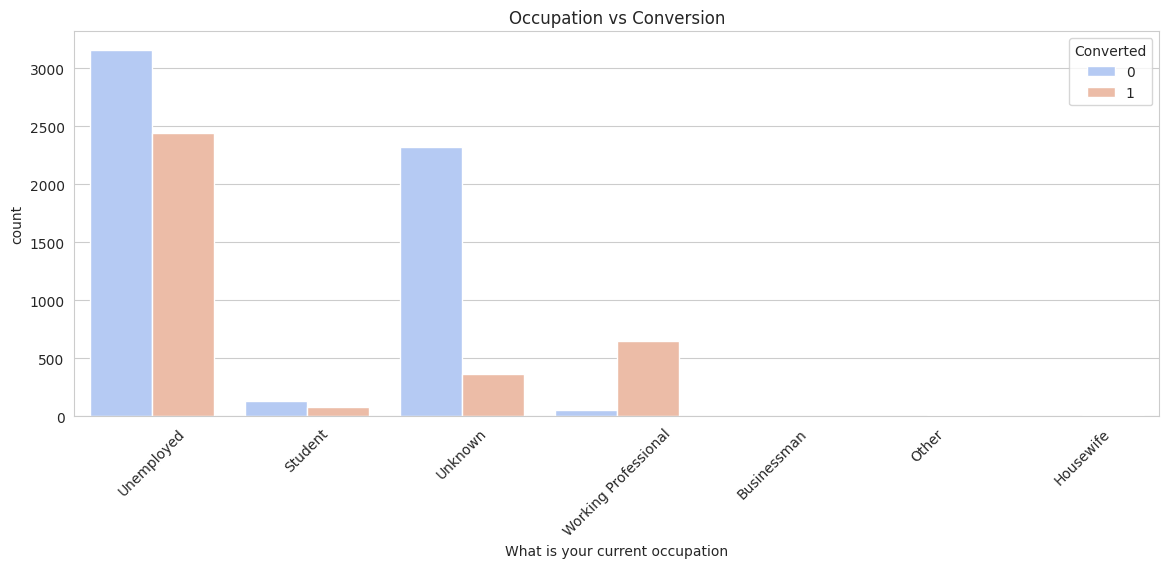

In [238]:
plt.figure(figsize=(14,5))

sns.countplot(
    data=df,
    x="What is your current occupation",
    hue="Converted",
    palette="coolwarm"
)

plt.xticks(rotation=45)

plt.title("Occupation vs Conversion")

plt.show()

# Last Activity vs Conversion

Last Activity represents the customer's most recent interaction with X Education.

Recent engagement is often a strong indicator of purchase intent.

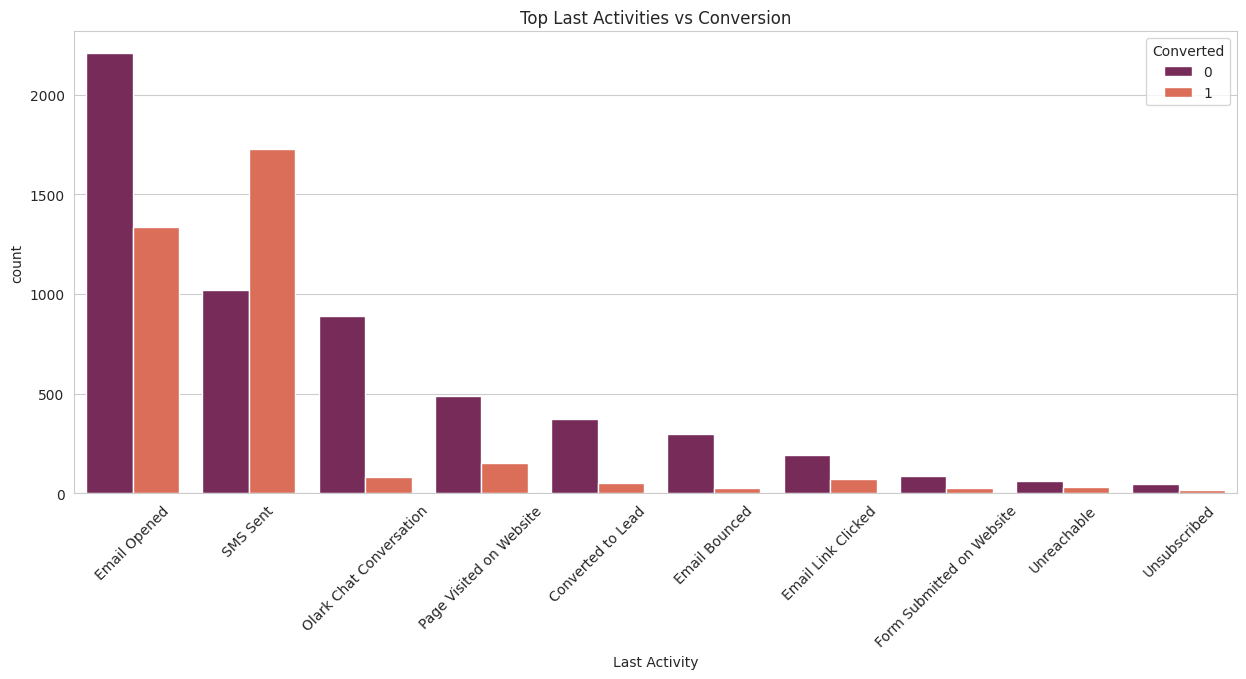

In [239]:
plt.figure(figsize=(15,6))

order = df["Last Activity"].value_counts().head(10).index

sns.countplot(
    data=df,
    x="Last Activity",
    hue="Converted",
    order=order,
    palette="rocket"
)

plt.xticks(rotation=45)

plt.title("Top Last Activities vs Conversion")

plt.show()

# Specialization vs Conversion

The customer's specialization may influence course preferences and purchasing decisions.

This analysis identifies academic backgrounds that are more likely to convert.

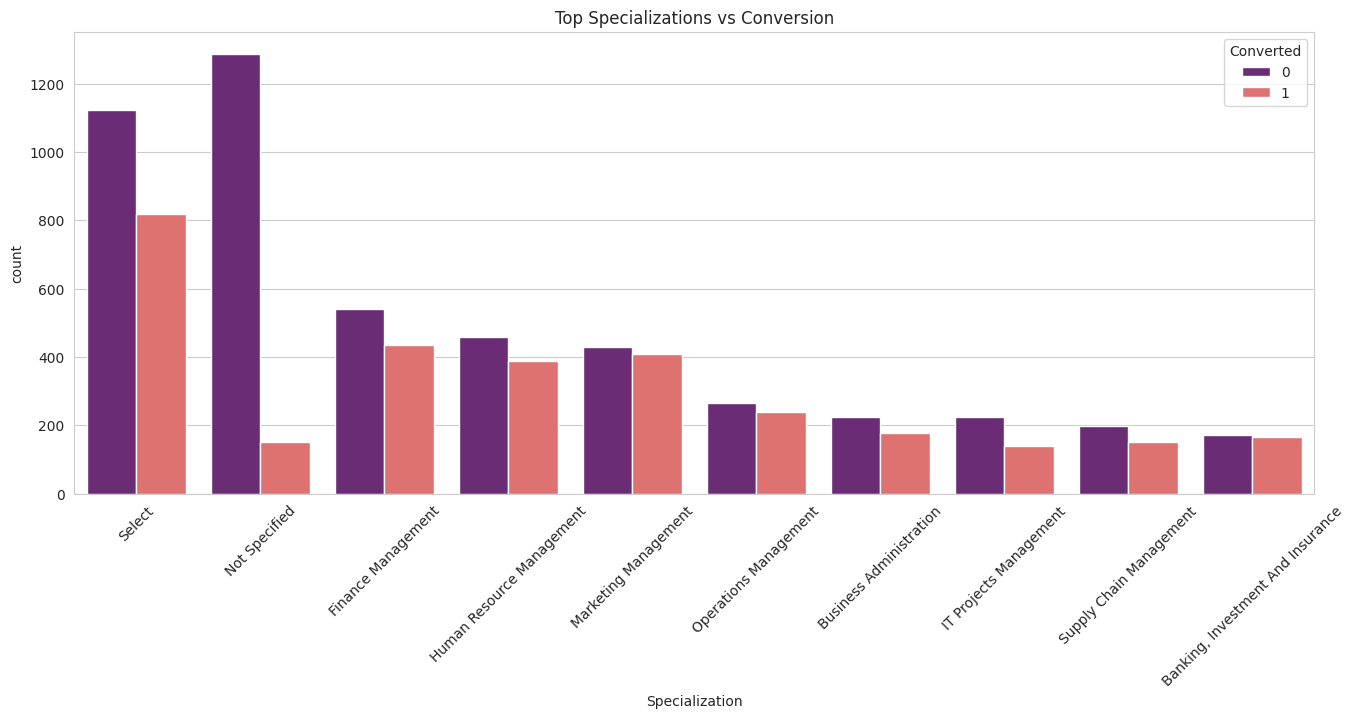

In [240]:
plt.figure(figsize=(16,6))

order = df["Specialization"].value_counts().head(10).index

sns.countplot(
    data=df,
    x="Specialization",
    hue="Converted",
    order=order,
    palette="magma"
)

plt.xticks(rotation=45)

plt.title("Top Specializations vs Conversion")

plt.show()

# Conversion Rate by Lead Source

Instead of comparing the total number of converted leads, this analysis calculates the conversion rate for each lead source.

This provides a more accurate measure of marketing effectiveness.

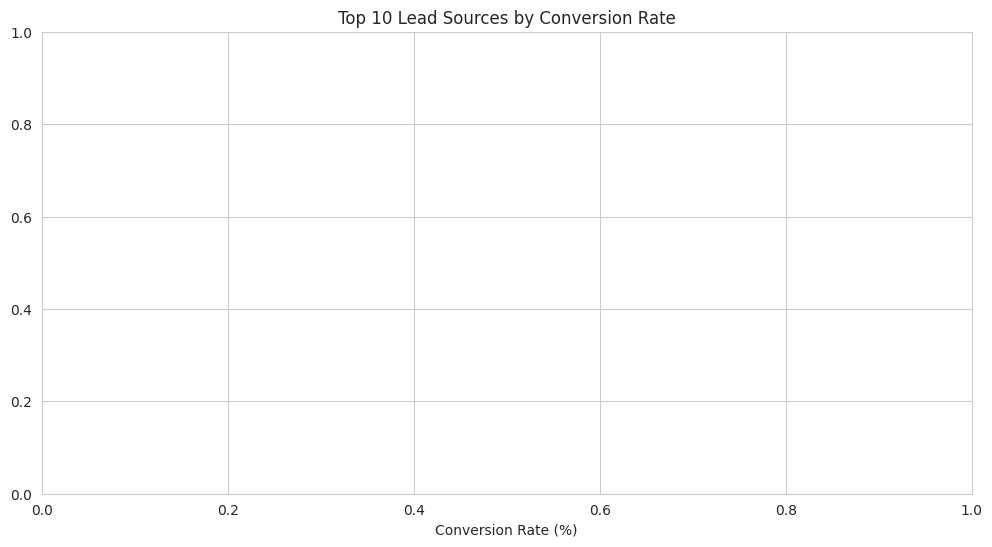

In [241]:
conversion_rate = (
    df.groupby("Lead Source")["Converted"]
      .value_counts(normalize=True)
      .rename("Rate")
      .mul(100)
      .reset_index()
)

conversion_rate = conversion_rate[
    conversion_rate["Converted"]=="Yes"
]

conversion_rate = conversion_rate.sort_values(
    "Rate",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=conversion_rate,
    x="Rate",
    y="Lead Source",
    palette="viridis"
)

plt.title("Top 10 Lead Sources by Conversion Rate")

plt.xlabel("Conversion Rate (%)")

plt.show()

# Exploratory Data Analysis Summary

Key observations from the analysis include:

- Website engagement is positively associated with lead conversion.
- Certain Lead Sources consistently generate higher-quality leads.
- Lead Origin influences conversion probability.
- Customer Occupation affects enrollment likelihood.
- Recent customer activity is an important indicator of purchase intent.
- Customer specialization also contributes to conversion behavior.

These insights suggest that customer engagement and acquisition channels play a significant role in predicting successful conversions.

# Feature Engineering & Data Preparation

Before training machine learning models, the dataset needs to be prepared.

The following preprocessing steps are performed:

- Separate features and target variable.
- Convert the target variable into numerical format.
- Identify numerical and categorical features.
- Apply appropriate preprocessing:
  - Standard Scaling for numerical features.
  - One-Hot Encoding for categorical features.
- Combine preprocessing using a ColumnTransformer.

This ensures that the dataset is suitable for machine learning algorithms while avoiding data leakage.

In [242]:
# Convert target variable into binary format

df["Converted"] = df["Converted"].map({
    "No": 0,
    "Yes": 1
})

In [243]:
X = df.drop("Converted", axis=1)
y = df["Converted"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (9240, 29)
Target Shape : (9240,)


In [244]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features :", len(categorical_cols))
print("Numerical Features :", len(numerical_cols))

Categorical Features : 26
Numerical Features : 3


In [245]:
df = pd.read_csv("Lead Scoring.csv")

In [246]:
print(df["Converted"].unique())
print(df["Converted"].head())

[0 1]
0    0
1    0
2    1
3    0
4    1
Name: Converted, dtype: int64


In [247]:
print(df["Converted"].unique())

[0 1]


In [248]:
print(df["Converted"].head(10))
print(df["Converted"].unique())
print(df["Converted"].isnull().sum())
print(df["Converted"].dtype)

0    0
1    0
2    1
3    0
4    1
5    0
6    1
7    0
8    0
9    0
Name: Converted, dtype: int64
[0 1]
0
int64


In [249]:
X = df.drop("Converted", axis=1)
y = df["Converted"]

In [250]:
print(y.isnull().sum())

0


In [251]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (7392, 36)
Testing Samples: (1848, 36)


In [252]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Logistic Regression

Logistic Regression is a widely used baseline algorithm for binary classification problems.

It estimates the probability that a lead will convert into a customer, making it well-suited for lead scoring.

In [253]:
df["Tags"] = df["Tags"].fillna("Not Available")

df["Lead Profile"] = df["Lead Profile"].fillna("Unknown")

df["What is your current occupation"] = df["What is your current occupation"].fillna("Unknown")

df["How did you hear about X Education"] = df["How did you hear about X Education"].fillna("Unknown")

df["Specialization"] = df["Specialization"].fillna("Not Specified")

df["City"] = df["City"].fillna("Unknown")

df["Country"] = df["Country"].fillna(df["Country"].mode()[0])

df["What matters most to you in choosing a course"] = \
df["What matters most to you in choosing a course"].fillna(
    df["What matters most to you in choosing a course"].mode()[0]
)

df["Last Activity"] = df["Last Activity"].fillna(
    df["Last Activity"].mode()[0]
)

df["Lead Source"] = df["Lead Source"].fillna(
    df["Lead Source"].mode()[0]
)

df["TotalVisits"] = df["TotalVisits"].fillna(
    df["TotalVisits"].median()
)

df["Page Views Per Visit"] = df["Page Views Per Visit"].fillna(
    df["Page Views Per Visit"].median()
)

In [254]:
print(df.isnull().sum().sum())

21639


In [255]:
X = df.drop("Converted", axis=1)
y = df["Converted"]

In [256]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

In [257]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [258]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [259]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Re-load the dataset to ensure a clean start for this modeling phase
df = pd.read_csv("Lead Scoring.csv")

# Ensure 'Converted' is numerical (outputs indicate it already is, but for robustness)
# This checks if 'Converted' is object type, which might contain 'Yes'/'No'
# If it's already 0/1, this mapping won't change it or introduce NaNs.
if df["Converted"].dtype == 'object':
    df["Converted"] = df["Converted"].map(
        {"No": 0,
         "Yes": 1
        })

# Drop identifier columns
df.drop(["Prospect ID", "Lead Number"], axis=1, inplace=True)

# Define high_missing_cols (as per notebook's earlier analysis)
high_missing_cols = [
    "Lead Quality",
    "Asymmetrique Activity Index",
    "Asymmetrique Activity Score",
    "Asymmetrique Profile Index",
    "Asymmetrique Profile Score"
]

# Drop columns with very high missing values
df.drop(columns=high_missing_cols, inplace=True)

# Handle remaining missing values (as per notebook's earlier imputation logic)
df["Tags"] = df["Tags"].fillna("Not Available")
df["Lead Profile"] = df["Lead Profile"].fillna("Unknown")
df["What is your current occupation"] = df["What is your current occupation"].fillna("Unknown")
df["How did you hear about X Education"] = df["How did you hear about X Education"].fillna("Unknown")
df["Specialization"] = df["Specialization"].fillna("Not Specified")
df["City"] = df["City"].fillna("Unknown")
df["Country"] = df["Country"].fillna(df["Country"].mode()[0])
df["What matters most to you in choosing a course"] = df["What matters most to you in choosing a course"].fillna(df["What matters most to you in choosing a course"].mode()[0])
df["Last Activity"] = df["Last Activity"].fillna(df["Last Activity"].mode()[0])
df["Lead Source"] = df["Lead Source"].fillna(df["Lead Source"].mode()[0])
df["TotalVisits"] = df["TotalVisits"].fillna(df["TotalVisits"].median())
df["Page Views Per Visit"] = df["Page Views Per Visit"].fillna(df["Page Views Per Visit"].median())

# Separate features and target variable
X = df.drop("Converted", axis=1)
y = df["Converted"]

# Identify numerical and categorical features from the cleaned X
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Define and fit the Logistic Regression model
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully with preprocessed data.")

Logistic Regression model trained successfully with preprocessed data.


In [260]:
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

In [261]:
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

# Model Evaluation

The model is evaluated using multiple performance metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

Using multiple metrics provides a comprehensive assessment of the model's predictive performance.

In [262]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Accuracy : 0.9286
Precision: 0.9227
Recall   : 0.889
F1 Score : 0.9056
ROC-AUC  : 0.976


In [263]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1136
           1       0.92      0.89      0.91       712

    accuracy                           0.93      1848
   macro avg       0.93      0.92      0.92      1848
weighted avg       0.93      0.93      0.93      1848



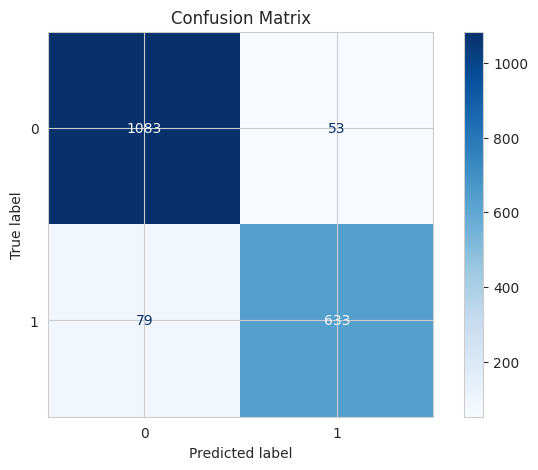

In [264]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

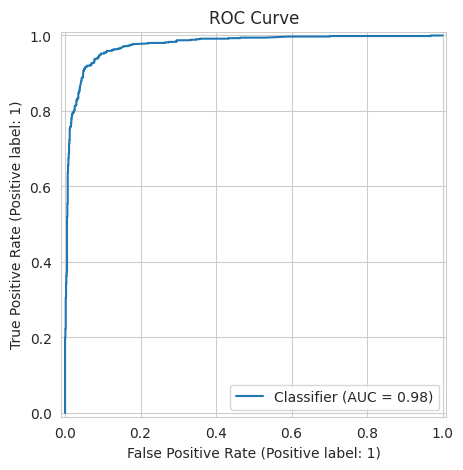

In [265]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")
plt.show()

# Decision Tree Classifier

Decision Trees classify data by recursively splitting it into smaller groups based on feature values.

They are easy to interpret and can capture non-linear relationships between features and the target variable.

In [266]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=6
    ))
])

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

In [267]:
print("Decision Tree Performance")
print("-"*30)

print("Accuracy :", round(accuracy_score(y_test, dt_pred),4))
print("Precision:", round(precision_score(y_test, dt_pred),4))
print("Recall   :", round(recall_score(y_test, dt_pred),4))
print("F1 Score :", round(f1_score(y_test, dt_pred),4))
print("ROC-AUC  :", round(roc_auc_score(y_test, dt_prob),4))

Decision Tree Performance
------------------------------
Accuracy : 0.9021
Precision: 0.9447
Recall   : 0.7921
F1 Score : 0.8617
ROC-AUC  : 0.9359


# Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees.

It generally provides better accuracy, reduces overfitting, and improves model stability.

In [268]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

In [269]:
print("Random Forest Performance")
print("-"*30)

print("Accuracy :", round(accuracy_score(y_test, rf_pred),4))
print("Precision:", round(precision_score(y_test, rf_pred),4))
print("Recall   :", round(recall_score(y_test, rf_pred),4))
print("F1 Score :", round(f1_score(y_test, rf_pred),4))
print("ROC-AUC  :", round(roc_auc_score(y_test, rf_prob),4))

Random Forest Performance
------------------------------
Accuracy : 0.9297
Precision: 0.9193
Recall   : 0.8961
F1 Score : 0.9075
ROC-AUC  : 0.975


In [270]:
import pandas as pd

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred)
    ],
    "Precision":[
        precision_score(y_test,y_pred),
        precision_score(y_test,dt_pred),
        precision_score(y_test,rf_pred)
    ],
    "Recall":[
        recall_score(y_test,y_pred),
        recall_score(y_test,dt_pred),
        recall_score(y_test,rf_pred)
    ],
    "F1 Score":[
        f1_score(y_test,y_pred),
        f1_score(y_test,dt_pred),
        f1_score(y_test,rf_pred)
    ],
    "ROC-AUC":[
        roc_auc_score(y_test,y_prob),
        roc_auc_score(y_test,dt_prob),
        roc_auc_score(y_test,rf_prob)
    ]
})

results = results.round(4)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9286,0.9227,0.8890,0.9056,0.9760
1,Decision Tree,0.9021,0.9447,0.7921,0.8617,0.9359
2,Random Forest,0.9297,0.9193,0.8961,0.9075,0.9750


In [271]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
0.9750995378111424


In [272]:
ohe = rf_model.named_steps["preprocessor"].named_transformers_["cat"]
feature_names = numerical_cols + list(ohe.get_feature_names_out(categorical_cols))

importances = rf_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
154,Tags_Will revert after reading the email,0.168769
1,Total Time Spent on Website,0.121327
149,Tags_Ringing,0.061266
192,Last Notable Activity_SMS Sent,0.040858
166,Lead Profile_Potential Lead,0.035456
39,Last Activity_SMS Sent,0.030145
136,Tags_Closed by Horizzon,0.029583
146,Tags_Not Available,0.028877
0,TotalVisits,0.027036
2,Page Views Per Visit,0.026872


# Lead Score Generation

The selected model predicts the probability of conversion for each lead.

This probability is multiplied by 100 to generate a Lead Score ranging from 0 to 100.

Higher scores indicate a greater likelihood of conversion and help the sales team prioritize leads effectively.

In [273]:
lead_scores = X_test.copy()

lead_scores["Actual Conversion"] = y_test.values

lead_scores["Conversion Probability"] = rf_prob

lead_scores["Lead Score"] = (
    lead_scores["Conversion Probability"] * 100
).round(2)

lead_scores.head(10)

,Lead Origin,Lead Source,Do Not Email,Do Not Call,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,...,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity,Actual Conversion,Conversion Probability,Lead Score
683,Landing Page Submission,Referral Sites,No,No,6.0,1505,6.0,Page Visited on Website,India,Human Resource Management,...,No,No,Unknown,Other Cities,No,Yes,Page Visited on Website,1,0.190000,19.00
1931,API,Olark Chat,No,No,0.0,0,0.0,SMS Sent,India,Select,...,No,No,Potential Lead,Select,No,No,Modified,1,0.865000,86.50
6950,Landing Page Submission,Direct Traffic,No,No,2.0,310,2.0,SMS Sent,India,Marketing Management,...,No,No,Select,Other Metro Cities,No,Yes,SMS Sent,0,0.035000,3.50
2996,Landing Page Submission,Direct Traffic,No,No,3.0,307,3.0,Email Opened,India,Finance Management,...,No,No,Select,Mumbai,No,Yes,Email Opened,0,0.005000,0.50
3902,Landing Page Submission,Direct Traffic,No,No,4.0,234,4.0,Email Link Clicked,India,Finance Management,...,No,No,Select,Thane & Outskirts,No,Yes,Email Link Clicked,0,0.025000,2.50
6828,Landing Page Submission,Direct Traffic,No,No,11.0,420,5.5,Email Opened,India,Business Administration,...,No,No,Select,Other Cities,No,Yes,Email Opened,0,0.100000,10.00
4906,API,Google,No,No,2.0,102,2.0,SMS Sent,India,Not Specified,...,No,No,Unknown,Unknown,No,No,SMS Sent,0,0.607885,60.79
5796,API,Olark Chat,No,No,0.0,0,0.0,Olark Chat Conversation,India,Select,...,No,No,Select,Select,No,No,Olark Chat Conversation,0,0.262397,26.24
6388,API,Olark Chat,No,No,0.0,0,0.0,Email Opened,India,Not Specified,...,No,No,Unknown,Unknown,No,No,Email Opened,0,0.062973,6.30
3636,API,bing,No,No,1.0,458,1.0,Converted to Lead,India,Not Specified,...,No,No,Unknown,Unknown,No,No,Modified,0,0.000000,0.00


In [274]:
def categorize(score):
    if score >= 80:
        return "Hot Lead"
    elif score >= 50:
        return "Warm Lead"
    else:
        return "Cold Lead"

lead_scores["Lead Category"] = lead_scores["Lead Score"].apply(categorize)

lead_scores.head(10)

,Lead Origin,Lead Source,Do Not Email,Do Not Call,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,...,Get updates on DM Content,Lead Profile,City,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity,Actual Conversion,Conversion Probability,Lead Score,Lead Category
683,Landing Page Submission,Referral Sites,No,No,6.0,1505,6.0,Page Visited on Website,India,Human Resource Management,...,No,Unknown,Other Cities,No,Yes,Page Visited on Website,1,0.190000,19.00,Cold Lead
1931,API,Olark Chat,No,No,0.0,0,0.0,SMS Sent,India,Select,...,No,Potential Lead,Select,No,No,Modified,1,0.865000,86.50,Hot Lead
6950,Landing Page Submission,Direct Traffic,No,No,2.0,310,2.0,SMS Sent,India,Marketing Management,...,No,Select,Other Metro Cities,No,Yes,SMS Sent,0,0.035000,3.50,Cold Lead
2996,Landing Page Submission,Direct Traffic,No,No,3.0,307,3.0,Email Opened,India,Finance Management,...,No,Select,Mumbai,No,Yes,Email Opened,0,0.005000,0.50,Cold Lead
3902,Landing Page Submission,Direct Traffic,No,No,4.0,234,4.0,Email Link Clicked,India,Finance Management,...,No,Select,Thane & Outskirts,No,Yes,Email Link Clicked,0,0.025000,2.50,Cold Lead
6828,Landing Page Submission,Direct Traffic,No,No,11.0,420,5.5,Email Opened,India,Business Administration,...,No,Select,Other Cities,No,Yes,Email Opened,0,0.100000,10.00,Cold Lead
4906,API,Google,No,No,2.0,102,2.0,SMS Sent,India,Not Specified,...,No,Unknown,Unknown,No,No,SMS Sent,0,0.607885,60.79,Warm Lead
5796,API,Olark Chat,No,No,0.0,0,0.0,Olark Chat Conversation,India,Select,...,No,Select,Select,No,No,Olark Chat Conversation,0,0.262397,26.24,Cold Lead
6388,API,Olark Chat,No,No,0.0,0,0.0,Email Opened,India,Not Specified,...,No,Unknown,Unknown,No,No,Email Opened,0,0.062973,6.30,Cold Lead
3636,API,bing,No,No,1.0,458,1.0,Converted to Lead,India,Not Specified,...,No,Unknown,Unknown,No,No,Modified,0,0.000000,0.00,Cold Lead


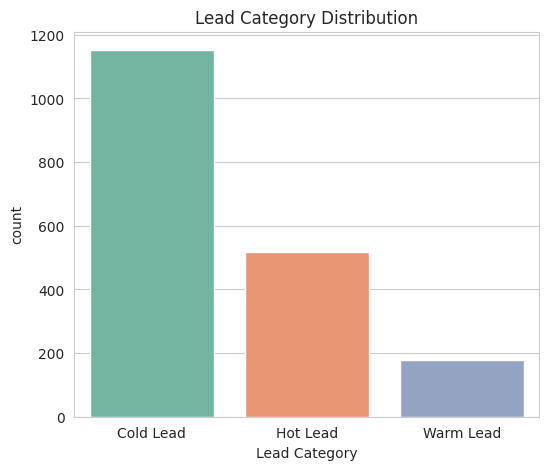

In [275]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=lead_scores,
    x="Lead Category",
    hue="Lead Category",
    legend=False,
    palette="Set2"
)

plt.title("Lead Category Distribution")

plt.show()

# Business Recommendations

Based on the analysis and predictive modeling, the following recommendations are proposed:

- Prioritize Hot Leads (Lead Score ≥ 80) for immediate follow-up.
- Assign Warm Leads (50–79) to nurturing campaigns through emails and calls.
- Reduce sales effort on Cold Leads (<50) and target them using low-cost marketing strategies.
- Focus marketing investments on high-performing Lead Sources.
- Encourage higher website engagement since increased time spent on the website is positively associated with conversions.
- Use the Lead Score model as a decision-support tool for the sales team to improve efficiency and increase conversion rates.

# Conclusion

This project developed a machine learning-based Lead Scoring system for X Education.

After cleaning the data, performing exploratory data analysis, and comparing multiple classification models, the best-performing model was selected to estimate the probability of lead conversion.

The predicted probabilities were converted into Lead Scores ranging from 0 to 100, enabling the sales team to prioritize high-potential leads effectively.

This data-driven approach can improve resource allocation, reduce time spent on low-quality leads, and support X Education's objective of increasing its conversion rate.

In [276]:
import joblib

joblib.dump(rf_model, "lead_scoring_model.pkl")

print("Model saved successfully!")

Model saved successfully!
